# Embedding analysis
This analysis has the following stages:
1. What is the correlation between satellite embeddings and the data elements from ACS that make up major area-based social risk indices? (see table of elements here: https://www.perplexity.ai/search/please-create-a-table-of-the-e-eCRKF361Ro._BO971qPZ3w)
2. Compare performance of penalized regression on embeddings at tract level to social risk indices at tract level *using CDC Places data*
    1. NOTE: Include tract area to avoid Modifiable Areal Unit Problem -- the effect of scale on aggregation of subunits -- i.e., rural units might have 1000 embeddings, while urban units might have 10.
3. Compare performance of penalized regression on embeddings at tract level to social risk indices + age / gender / raceeth at patient level *using AFC data*
4. For each of 2 and 3, do penalized regression on residual of social risk index regression to see what share of the unexplained variation from social risk indices can be captured by spatial embeddings
5. Assess heterogeneity of embedding performance across cities / regions / tract sizes

## Q1: What's the correlation between embeddings and the data elements from ACS that make up major area-based social risk indices?
We're using data from ReADI, SDI, and SVI. The script `get_data.py` pulls tract-level ACS data from the Census API (if it's not already present in the `data` folder). Then, we use LightGBM to estimate how much of the variance in tract-level values can be explained by embeddings.

In [33]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import polars as pl
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import lightgbm as lgb
import matplotlib.pyplot as plt

DATA_DIR    = Path("../../data")
OUTPUTS_DIR = Path("../../outputs")
OUTPUTS_DIR.mkdir(exist_ok=True)

# ── Cache control ─────────────────────────────────────────────────────────────
# When True, each model cell loads its CSV from OUTPUTS_DIR instead of refitting.
# Set to False to rerun all LightGBM models from scratch.
USE_CACHED = True

STAT_SUFFIXES = ["MEAN", "MEDIAN", "MINIMUM", "MAXIMUM", "STD"]
EMB_COLS = [f"A{i:02d}_{s}" for i in range(64) for s in STAT_SUFFIXES]  # 320 cols
FEATURE_COLS = EMB_COLS + ["ALAND", "AWATER"]

In [34]:
acs_path = DATA_DIR / "acs.csv"

if not acs_path.exists():
    print("data/acs.csv not found — running get_data.py (~5 min for all 50 states)...")
    result = subprocess.run(
        [sys.executable, "get_data.py"],
        capture_output=True,
        text=True,
    )
    print(result.stdout[-3_000:] if len(result.stdout) > 3_000 else result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
else:
    print(f"✓  ACS data present: {acs_path}")

✓  ACS data present: ../../data/acs.csv


In [35]:
# Data is already aggregated to tract level; just filter to 2022 and select
# the embedding stat columns plus land/water area as geographic controls.
emb_tract = (
    pl.read_csv(DATA_DIR / "alphaearth_embeddings.csv", infer_schema_length=10_000)
    .filter((pl.col("year") == 2022) & pl.col("A00_MAXIMUM").is_not_null())
    .with_columns(
        pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips")
    )
    .select(["tract_fips"] + EMB_COLS + ["ALAND", "AWATER"])
)

print(f"Tracts with 2022 embeddings: {len(emb_tract):,}")
print(f"Feature columns: {len(FEATURE_COLS)}  ({len(EMB_COLS)} embedding stats + 2 area)")
emb_tract.head(3)

Tracts with 2022 embeddings: 78,565
Feature columns: 322  (320 embedding stats + 2 area)


tract_fips,A00_MEAN,A00_MEDIAN,A00_MINIMUM,A00_MAXIMUM,A00_STD,A01_MEAN,A01_MEDIAN,A01_MINIMUM,A01_MAXIMUM,A01_STD,A02_MEAN,A02_MEDIAN,A02_MINIMUM,A02_MAXIMUM,A02_STD,A03_MEAN,A03_MEDIAN,A03_MINIMUM,A03_MAXIMUM,A03_STD,A04_MEAN,A04_MEDIAN,A04_MINIMUM,A04_MAXIMUM,A04_STD,A05_MEAN,A05_MEDIAN,A05_MINIMUM,A05_MAXIMUM,A05_STD,A06_MEAN,A06_MEDIAN,A06_MINIMUM,A06_MAXIMUM,A06_STD,A07_MEAN,…,A57_MEAN,A57_MEDIAN,A57_MINIMUM,A57_MAXIMUM,A57_STD,A58_MEAN,A58_MEDIAN,A58_MINIMUM,A58_MAXIMUM,A58_STD,A59_MEAN,A59_MEDIAN,A59_MINIMUM,A59_MAXIMUM,A59_STD,A60_MEAN,A60_MEDIAN,A60_MINIMUM,A60_MAXIMUM,A60_STD,A61_MEAN,A61_MEDIAN,A61_MINIMUM,A61_MAXIMUM,A61_STD,A62_MEAN,A62_MEDIAN,A62_MINIMUM,A62_MAXIMUM,A62_STD,A63_MEAN,A63_MEDIAN,A63_MINIMUM,A63_MAXIMUM,A63_STD,ALAND,AWATER
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
"""25017342501""",0.045442,0.048228,0.048228,0.048228,0.0,-0.329065,-0.327812,-0.327812,-0.327812,0.0,0.021964,0.017778,0.017778,0.017778,0.0,-0.104748,-0.108512,-0.108512,-0.108512,0.0,0.038343,0.041584,0.041584,0.041584,0.0,-0.186998,-0.186082,-0.186082,-0.186082,0.0,-0.106276,-0.103406,-0.103406,-0.103406,0.0,-0.185179,…,0.0924115,0.093564,0.093564,0.093564,0.0,-0.027204,-0.027128,-0.027128,-0.027128,0.0,-0.062964,-0.06699,-0.06699,-0.06699,0.0,0.088536,0.088827,0.088827,0.088827,0.0,-0.020823,-0.022207,-0.022207,-0.022207,0.0,-0.241473,-0.244152,-0.244152,-0.244152,0.0,0.08242,0.084214,0.084214,0.084214,0.0,529324,0
"""17031816300""",0.053342,0.048228,0.048228,0.048228,0.0,-0.302769,-0.318893,-0.318893,-0.318893,0.0,0.140234,0.147697,0.147697,0.147697,0.0,-0.135776,-0.113741,-0.113741,-0.113741,0.0,0.117537,0.124567,0.124567,0.124567,0.0,-0.033559,-0.022207,-0.022207,-0.022207,0.0,-0.140111,-0.135886,-0.135886,-0.135886,0.0,-0.17706,…,0.068218,0.062991,0.062991,0.062991,0.0,0.082159,0.062991,0.062991,0.062991,0.0,-0.047131,-0.051734,-0.051734,-0.051734,0.0,0.067418,0.084214,0.084214,0.084214,0.0,0.033696,0.062991,0.062991,0.062991,0.0,-0.249314,-0.244152,-0.244152,-0.244152,0.0,0.048262,0.051734,0.051734,0.051734,0.0,924162,0
"""31055000700""",0.042061,0.038447,0.038447,0.038447,0.0,-0.355413,-0.35531,-0.35531,-0.35531,0.0,0.208464,0.214133,0.214133,0.214133,0.0,-0.149801,-0.147697,-0.147697,-0.147697,0.0,0.090287,0.088827,0.088827,0.088827,0.0,-0.003767,-0.007443,-0.017778,-0.017778,0.0,-0.116339,-0.119093,-0.119093,-0.119093,0.0,-0.092124,…,0.070022,0.062991,0.079723,0.079723,0.0,0.035816,0.029773,0.027128,0.027128,0.0,0.15231,0.153787,0.16,0.16,0.0,-0.019568,-0.022207,-0.022207,-0.022207,0.0,-0.018396,-0.013841,-0.013841,-0.013841,0.0,-0.250633,-0.236463,-0.236463,-0.236463,0.0,-0.01109,-0.019931,-0.019931,-0.019931,0.0,928439,0


In [36]:
# Prefer 2022 data where available; fall back to 2023 for measures not yet in 2022 release.
_places_raw = pl.read_csv(
    DATA_DIR / "PLACES__Local_Data_for_Better_Health__Census_Tract_Data__2025_release.csv",
    infer_schema_length=10_000,
)

# MeasureId → Short_Question_Text for readable axis labels in visualizations
PLACES_LABELS: dict[str, str] = dict(
    _places_raw.select(["MeasureId", "Short_Question_Text"])
    .unique()
    .iter_rows()
)

_places_long = (
    _places_raw
    .filter(pl.col("Year").is_in([2022, 2023]))
    .select(["Year", "LocationID", "MeasureId", "Data_Value"])
    .with_columns(
        pl.col("LocationID").cast(pl.Utf8).str.zfill(11).alias("tract_fips")
    )
    .drop("LocationID")
)

_measures_2022 = set(
    _places_long.filter(pl.col("Year") == 2022)["MeasureId"].unique().to_list()
)
_measures_2023_only = set(
    _places_long.filter(pl.col("Year") == 2023)["MeasureId"].unique().to_list()
) - _measures_2022

places_wide = (
    pl.concat([
        _places_long.filter((pl.col("Year") == 2022) & pl.col("MeasureId").is_in(_measures_2022)),
        _places_long.filter((pl.col("Year") == 2023) & pl.col("MeasureId").is_in(_measures_2023_only)),
    ])
    .drop("Year")
    .pivot(on="MeasureId", index="tract_fips", values="Data_Value")
)

PLACES_MEASURES = sorted([c for c in places_wide.columns if c != "tract_fips"])
print(f"PLACES: {len(places_wide):,} tracts × {len(PLACES_MEASURES)} measures")
print(f"  2022 measures ({len(_measures_2022)}): {sorted(_measures_2022)}")
print(f"  2023 fill-in ({len(_measures_2023_only)}): {sorted(_measures_2023_only)}")
places_wide.head(3)

PLACES: 83,522 tracts × 40 measures
  2022 measures (5): ['COLON_SCREEN', 'DENTAL', 'MAMMOUSE', 'SLEEP', 'TEETHLOST']
  2023 fill-in (35): ['ACCESS2', 'ARTHRITIS', 'BINGE', 'BPHIGH', 'BPMED', 'CANCER', 'CASTHMA', 'CHD', 'CHECKUP', 'CHOLSCREEN', 'COGNITION', 'COPD', 'CSMOKING', 'DEPRESSION', 'DIABETES', 'DISABILITY', 'EMOTIONSPT', 'FOODINSECU', 'FOODSTAMP', 'GHLTH', 'HEARING', 'HIGHCHOL', 'HOUSINSECU', 'INDEPLIVE', 'LACKTRPT', 'LONELINESS', 'LPA', 'MHLTH', 'MOBILITY', 'OBESITY', 'PHLTH', 'SELFCARE', 'SHUTUTILITY', 'STROKE', 'VISION']


tract_fips,MAMMOUSE,SLEEP,COLON_SCREEN,DENTAL,TEETHLOST,DISABILITY,DEPRESSION,ARTHRITIS,OBESITY,STROKE,DIABETES,CANCER,CASTHMA,HEARING,VISION,BINGE,MOBILITY,GHLTH,BPHIGH,CHD,MHLTH,LACKTRPT,HIGHCHOL,COPD,SELFCARE,INDEPLIVE,COGNITION,FOODINSECU,CHOLSCREEN,CHECKUP,HOUSINSECU,PHLTH,LPA,EMOTIONSPT,ACCESS2,CSMOKING,FOODSTAMP,LONELINESS,SHUTUTILITY,BPMED
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""01001020200""",79.2,42.6,68.1,56.1,15.9,36.9,23.3,29.5,44.7,4.4,15.8,6.3,10.8,6.7,6.6,12.9,17.8,25.1,45.9,6.5,18.5,12.0,39.7,7.6,5.0,10.4,17.3,24.8,85.6,81.8,18.5,14.4,32.0,29.1,10.6,16.7,18.4,36.1,12.5,78.3
"""01015002502""",75.5,39.9,65.2,56.5,15.4,38.1,25.4,34.1,36.4,4.2,14.2,9.7,10.1,9.7,5.5,15.0,18.0,23.8,44.8,8.3,17.5,7.9,43.1,9.5,4.4,9.8,16.5,15.5,86.1,79.1,10.4,15.7,30.2,23.0,9.2,16.7,10.8,34.6,7.0,78.5
"""01003010707""",77.6,31.2,72.9,73.6,8.6,28.3,21.3,30.2,30.4,3.0,10.3,10.9,8.7,7.9,3.3,16.0,11.7,13.7,39.1,6.1,13.2,4.5,41.1,5.2,2.5,6.0,11.1,7.5,89.9,80.9,6.3,10.6,19.2,18.7,5.6,9.0,4.0,29.9,4.0,78.6


In [37]:
ACS_RENAME = {
    # --- Poverty ---
    "B17021_001E": "pov_universe",
    "B17021_002E": "pov_below_related_children",
    "B17021_003E": "pov_below_other",
    "S1701_C01_001E": "pov_determination_universe",
    "S1701_C01_040E": "pct_below_150pct_poverty",
    "S1701_C02_001E": "pct_below_100pct_poverty",
    # --- Income ---
    "B19001_002E": "hh_income_lt10k",
    "B19001_017E": "hh_income_ge200k",
    "B19113_001E": "median_family_income",
    "B19301_001E": "per_capita_income",
    # --- Employment ---
    "B23025_003E": "labor_force",
    "B23025_005E": "unemployed",
    "DP03_0009PE": "unemployment_pct",
    "S2301_C04_001E": "not_in_labor_force_pct",
    # --- Education ---
    "B15003_001E": "educ_universe",
    "B15003_002E": "educ_no_schooling",
    "B15003_003E": "educ_nursery",
    "B15003_004E": "educ_kindergarten",
    "B15003_005E": "educ_grade1",
    "B15003_006E": "educ_grade2",
    "B15003_007E": "educ_grade3",
    "B15003_008E": "educ_grade4",
    "B15003_009E": "educ_grade5",
    "B15003_010E": "educ_grade6",
    "B15003_011E": "educ_grade7",
    "B15003_012E": "educ_grade8",
    "B15003_013E": "educ_grade9",
    "B15003_014E": "educ_grade10",
    "B15003_015E": "educ_grade11",
    "B15003_016E": "educ_grade12_no_diploma",
    "B15003_017E": "educ_hs_diploma",
    "B15003_018E": "educ_ged",
    "B15003_019E": "educ_some_college_lt1yr",
    "B15003_020E": "educ_some_college_ge1yr",
    "B15003_021E": "educ_associates",
    "B15003_022E": "educ_bachelors",
    "B15003_023E": "educ_masters",
    "B15003_024E": "educ_professional_degree",
    "B15003_025E": "educ_doctorate",
    "S0601_C01_001E": "pop_25plus",
    "S0601_C01_033E": "no_hs_diploma_pct",
    # --- Language (limited English proficiency) ---
    "B16005_001E": "lang_universe",
    "B16005_007E": "lep_spanish_native_not_well",
    "B16005_008E": "lep_spanish_native_not_at_all",
    "B16005_012E": "lep_spanish_foreign_not_well",
    "B16005_013E": "lep_spanish_foreign_not_at_all",
    "B16005_017E": "lep_indo_euro_native_not_well",
    "B16005_018E": "lep_indo_euro_native_not_at_all",
    "B16005_022E": "lep_indo_euro_foreign_not_well",
    "B16005_023E": "lep_indo_euro_foreign_not_at_all",
    "B16005_029E": "lep_asian_pac_native_not_well",
    "B16005_030E": "lep_asian_pac_native_not_at_all",
    "B16005_034E": "lep_asian_pac_foreign_not_well",
    "B16005_035E": "lep_asian_pac_foreign_not_at_all",
    "B16005_039E": "lep_other_native_not_well",
    "B16005_040E": "lep_other_native_not_at_all",
    "B16005_044E": "lep_other_foreign_not_well",
    "B16005_045E": "lep_other_foreign_not_at_all",
    # --- Occupation (white-collar components for ADI) ---
    "C24010_001E": "occ_universe",
    "C24010_019E": "occ_male_mgmt_business_science_arts",
    "C24010_020E": "occ_male_business_financial",
    "C24010_021E": "occ_male_computer_engineering_science",
    "C24010_022E": "occ_male_education_legal_arts",
    "C24010_023E": "occ_male_healthcare_practitioners",
    "C24010_024E": "occ_male_service",
    "C24010_025E": "occ_male_sales_office",
    "C24010_039E": "occ_female_mgmt_business_science_arts",
    "C24010_040E": "occ_female_business_financial",
    "C24010_041E": "occ_female_computer_engineering_science",
    "C24010_042E": "occ_female_education_legal_arts",
    "C24010_043E": "occ_female_healthcare_practitioners",
    "C24010_044E": "occ_female_service",
    "C24010_045E": "occ_female_sales_office",
    # --- Housing ---
    "B25064_001E": "median_gross_rent",
    "B25077_001E": "median_home_value",
    "B25003_001E": "tenure_universe",
    "B25003_002E": "owner_occupied_units",
    "B25014_001E": "occupants_per_room_universe",
    "B25014_005E": "overcrowded_owner_1_to_1_5_per_room",
    "B25014_006E": "overcrowded_owner_1_5_to_2_per_room",
    "B25014_007E": "overcrowded_owner_2plus_per_room",
    "B25040_001E": "heating_fuel_universe",
    "B25040_003E": "heating_fuel_utility_gas",
    "B25044_001E": "vehicle_availability_universe",
    "B25044_003E": "owner_occupied_no_vehicle",
    "B25044_010E": "renter_occupied_no_vehicle",
    "B25047_001E": "plumbing_universe",
    "B25047_002E": "incomplete_plumbing",
    "B26001_001E": "group_quarters_pop",
    "S2503_C01_001E": "renter_units_universe",
    "S2503_C01_028E": "rent_30_34pct_of_income",
    "S2503_C01_032E": "rent_35_39pct_of_income",
    "S2503_C01_036E": "rent_40_49pct_of_income",
    "S2503_C01_040E": "rent_50plus_pct_of_income",
    # --- Demographics ---
    "DP05_0001E": "total_pop",
    "DP05_0019PE": "age_lte17_pct",
    "DP05_0079E": "nh_white_alone",
    "S0101_C02_030E": "age_65plus_pct",
    # --- Households & disability ---
    "DP02_0001E": "total_households",
    "DP02_0007PE": "single_parent_male_hh_pct",
    "DP02_0011PE": "single_parent_female_hh_pct",
    "DP02_0072PE": "disability_pct",
    # --- Housing characteristics ---
    "DP04_0012PE": "structures_10_19_units_pct",
    "DP04_0013PE": "structures_20plus_units_pct",
    "DP04_0014PE": "mobile_homes_pct",
    "DP04_0047PE": "renter_occupied_pct",
    "DP04_0058PE": "no_vehicle_pct",
    "DP04_0078PE": "overcrowded_owner_pct",
    "DP04_0079PE": "overcrowded_renter_pct",
    # --- Health insurance ---
    "S2701_C05_001E": "uninsured_pct",
}

# Each tuple: (numerator, denominator, new_name)
# new_name=None → append "_pct" to the numerator name
_CONVERSIONS = [
    # Poverty
    ("pov_below_related_children",         "pov_universe",                None),
    ("pov_below_other",                    "pov_universe",                None),
    # Income (share of households in each bracket)
    ("hh_income_lt10k",                    "total_households",            None),
    ("hh_income_ge200k",                   "total_households",            None),
    # Education (share of adults 25+ at each attainment level)
    ("educ_no_schooling",                  "educ_universe",               None),
    ("educ_nursery",                       "educ_universe",               None),
    ("educ_kindergarten",                  "educ_universe",               None),
    ("educ_grade1",                        "educ_universe",               None),
    ("educ_grade2",                        "educ_universe",               None),
    ("educ_grade3",                        "educ_universe",               None),
    ("educ_grade4",                        "educ_universe",               None),
    ("educ_grade5",                        "educ_universe",               None),
    ("educ_grade6",                        "educ_universe",               None),
    ("educ_grade7",                        "educ_universe",               None),
    ("educ_grade8",                        "educ_universe",               None),
    ("educ_grade9",                        "educ_universe",               None),
    ("educ_grade10",                       "educ_universe",               None),
    ("educ_grade11",                       "educ_universe",               None),
    ("educ_grade12_no_diploma",            "educ_universe",               None),
    ("educ_hs_diploma",                    "educ_universe",               None),
    ("educ_ged",                           "educ_universe",               None),
    ("educ_some_college_lt1yr",            "educ_universe",               None),
    ("educ_some_college_ge1yr",            "educ_universe",               None),
    ("educ_associates",                    "educ_universe",               None),
    ("educ_bachelors",                     "educ_universe",               None),
    ("educ_masters",                       "educ_universe",               None),
    ("educ_professional_degree",           "educ_universe",               None),
    ("educ_doctorate",                     "educ_universe",               None),
    # Language (share of tract population with limited English by group)
    ("lep_spanish_native_not_well",        "lang_universe",               None),
    ("lep_spanish_native_not_at_all",      "lang_universe",               None),
    ("lep_spanish_foreign_not_well",       "lang_universe",               None),
    ("lep_spanish_foreign_not_at_all",     "lang_universe",               None),
    ("lep_indo_euro_native_not_well",      "lang_universe",               None),
    ("lep_indo_euro_native_not_at_all",    "lang_universe",               None),
    ("lep_indo_euro_foreign_not_well",     "lang_universe",               None),
    ("lep_indo_euro_foreign_not_at_all",   "lang_universe",               None),
    ("lep_asian_pac_native_not_well",      "lang_universe",               None),
    ("lep_asian_pac_native_not_at_all",    "lang_universe",               None),
    ("lep_asian_pac_foreign_not_well",     "lang_universe",               None),
    ("lep_asian_pac_foreign_not_at_all",   "lang_universe",               None),
    ("lep_other_native_not_well",          "lang_universe",               None),
    ("lep_other_native_not_at_all",        "lang_universe",               None),
    ("lep_other_foreign_not_well",         "lang_universe",               None),
    ("lep_other_foreign_not_at_all",       "lang_universe",               None),
    # Occupation (share of employed civilians in each category)
    ("occ_male_mgmt_business_science_arts",    "occ_universe",            None),
    ("occ_male_business_financial",            "occ_universe",            None),
    ("occ_male_computer_engineering_science",  "occ_universe",            None),
    ("occ_male_education_legal_arts",          "occ_universe",            None),
    ("occ_male_healthcare_practitioners",      "occ_universe",            None),
    ("occ_male_service",                       "occ_universe",            None),
    ("occ_male_sales_office",                  "occ_universe",            None),
    ("occ_female_mgmt_business_science_arts",  "occ_universe",            None),
    ("occ_female_business_financial",          "occ_universe",            None),
    ("occ_female_computer_engineering_science","occ_universe",            None),
    ("occ_female_education_legal_arts",        "occ_universe",            None),
    ("occ_female_healthcare_practitioners",    "occ_universe",            None),
    ("occ_female_service",                     "occ_universe",            None),
    ("occ_female_sales_office",                "occ_universe",            None),
    # Housing
    ("owner_occupied_units",               "tenure_universe",             "owner_occupied_pct"),
    ("overcrowded_owner_1_to_1_5_per_room","occupants_per_room_universe", None),
    ("overcrowded_owner_1_5_to_2_per_room","occupants_per_room_universe", None),
    ("overcrowded_owner_2plus_per_room",   "occupants_per_room_universe", None),
    ("heating_fuel_utility_gas",           "heating_fuel_universe",       "heating_fuel_utility_gas_pct"),
    ("owner_occupied_no_vehicle",          "vehicle_availability_universe","owner_occupied_no_vehicle_pct"),
    ("renter_occupied_no_vehicle",         "vehicle_availability_universe","renter_occupied_no_vehicle_pct"),
    ("incomplete_plumbing",                "plumbing_universe",           "incomplete_plumbing_pct"),
    ("group_quarters_pop",                 "total_pop",                   "group_quarters_pct"),
    ("nh_white_alone",                     "total_pop",                   "nh_white_pct"),
    # Housing cost burden (share of renters paying X% of income on rent)
    ("rent_30_34pct_of_income",            "renter_units_universe",       "cost_burdened_rent_30_34_pct"),
    ("rent_35_39pct_of_income",            "renter_units_universe",       "cost_burdened_rent_35_39_pct"),
    ("rent_40_49pct_of_income",            "renter_units_universe",       "cost_burdened_rent_40_49_pct"),
    ("rent_50plus_pct_of_income",          "renter_units_universe",       "cost_burdened_rent_50plus_pct"),
]

if acs_path.exists():
    _acs_raw = (
        pl.read_csv(acs_path, infer_schema_length=5_000)
        .with_columns(
            pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips")
        )
        .drop(["GEOID", "NAME"])
    )
    acs = _acs_raw.rename({k: v for k, v in ACS_RENAME.items() if k in _acs_raw.columns})

    # Filter to conversions where both columns are present, then compute
    _available = set(acs.columns)
    _valid = [(n, d, name) for n, d, name in _CONVERSIONS if n in _available and d in _available]
    acs = acs.with_columns([
        (pl.col(num) / pl.col(den) * 100).alias(name or f"{num}_pct")
        for num, den, name in _valid
    ]).drop([
        c for c in (
            [num for num, _, _ in _valid]
            + ["pov_universe", "pov_determination_universe", "educ_universe", "pop_25plus",
               "lang_universe", "occ_universe", "tenure_universe", "occupants_per_room_universe",
               "heating_fuel_universe", "vehicle_availability_universe", "plumbing_universe",
               "renter_units_universe", "labor_force", "unemployed"]
        ) if c in _available
    ])

    ACS_VARS = [c for c in acs.columns if c != "tract_fips"]
    print(f"ACS: {len(acs):,} tracts × {len(ACS_VARS)} variables")
else:
    acs = None
    ACS_VARS = []
    print("ACS not available — run get_data.py above to pull from Census API")

ACS: 84,415 tracts × 96 variables


In [38]:
# ── Composite index variables ─────────────────────────────────────────────────
# Each index uses aggregated indicators, not the raw ACS sub-components.
# This cell sums/combines the individual columns (kept for completeness) into
# the composite variables that SVI, SDI, and ADI actually operationalise.

if acs is not None:
    _lep_cols    = [c for c in acs.columns if c.startswith("lep_") and c.endswith("_pct")]
    _lt9_cols    = [
        "educ_no_schooling_pct", "educ_nursery_pct", "educ_kindergarten_pct",
        "educ_grade1_pct", "educ_grade2_pct", "educ_grade3_pct",
        "educ_grade4_pct", "educ_grade5_pct", "educ_grade6_pct", "educ_grade7_pct",
    ]
    _lt12_cols   = _lt9_cols + [
        "educ_grade8_pct", "educ_grade9_pct", "educ_grade10_pct",
        "educ_grade11_pct", "educ_grade12_no_diploma_pct",
    ]
    _hsplus_cols = [
        "educ_hs_diploma_pct", "educ_ged_pct", "educ_some_college_lt1yr_pct",
        "educ_some_college_ge1yr_pct", "educ_associates_pct", "educ_bachelors_pct",
        "educ_masters_pct", "educ_professional_degree_pct", "educ_doctorate_pct",
    ]
    _occ_cols    = [c for c in acs.columns if c.startswith("occ_") and c.endswith("_pct")]
    _burden_cols = [
        "cost_burdened_rent_30_34_pct", "cost_burdened_rent_35_39_pct",
        "cost_burdened_rent_40_49_pct", "cost_burdened_rent_50plus_pct",
    ]

    acs = acs.with_columns([
        # SVI: EP_LIMENG — speaks English less than very well (all 16 B16005 components)
        pl.sum_horizontal([pl.col(c) for c in _lep_cols]).alias("lep_total_pct"),
        # SVI / SDI: EP_SNGPNT — single-parent households
        (pl.col("single_parent_male_hh_pct") + pl.col("single_parent_female_hh_pct")).alias("single_parent_pct"),
        # SVI / SDI: EP_CROWD — crowded housing (DP04, >1 person/room)
        (pl.col("overcrowded_owner_pct") + pl.col("overcrowded_renter_pct")).alias("crowded_housing_pct"),
        # SVI: EP_MUNIT — multi-unit structures (10+ units)
        (pl.col("structures_10_19_units_pct") + pl.col("structures_20plus_units_pct")).alias("multi_unit_housing_pct"),
        # SVI: EP_HBURD — renter housing cost burden (≥30% of income on rent)
        pl.sum_horizontal([pl.col(c) for c in _burden_cols]).alias("housing_cost_burdened_pct"),
        # SVI: EP_MINRTY — minority (non-white) population
        (100.0 - pl.col("nh_white_pct")).alias("minority_pct"),
        # ADI: ADI_PCT_BELOW_POVERTY — below poverty (B17021 components)
        (pl.col("pov_below_related_children_pct") + pl.col("pov_below_other_pct")).alias("pov_total_pct"),
        # ADI: ADI_PCT_LT9_ED — less than 9th-grade education (B15003_002–011E)
        pl.sum_horizontal([pl.col(c) for c in _lt9_cols]).alias("educ_lt9th_grade_pct"),
        # ADI: ADI_PCT_HSPLUS — high school diploma or higher (B15003_017–025E)
        pl.sum_horizontal([pl.col(c) for c in _hsplus_cols]).alias("educ_hs_or_higher_pct"),
        # SDI: SDI_ED_LT12_PCT — less than high school diploma (B15003_002–016E)
        pl.sum_horizontal([pl.col(c) for c in _lt12_cols]).alias("educ_lt12th_grade_pct"),
        # ADI: ADI_PCT_WHITE_COLLAR — white-collar occupations (all C24010 professional categories)
        pl.sum_horizontal([pl.col(c) for c in _occ_cols]).alias("white_collar_pct"),
        # ADI: ADI_NO_VEHICLE_PCT — households with no vehicle (B25044)
        (pl.col("owner_occupied_no_vehicle_pct") + pl.col("renter_occupied_no_vehicle_pct")).alias("no_vehicle_b25044_pct"),
        # ADI: ADI_CROWDING_PCT — crowded housing by severity (B25014, >1 person/room)
        pl.sum_horizontal([
            pl.col("overcrowded_owner_1_to_1_5_per_room_pct"),
            pl.col("overcrowded_owner_1_5_to_2_per_room_pct"),
            pl.col("overcrowded_owner_2plus_per_room_pct"),
        ]).alias("crowded_b25014_pct"),
        # ADI: ADI_INCOME_DISPARITY — ratio of lowest to highest income bracket
        (pl.col("hh_income_lt10k_pct") /
         pl.when(pl.col("hh_income_ge200k_pct") > 0)
           .then(pl.col("hh_income_ge200k_pct"))
           .otherwise(None)
        ).alias("income_disparity_ratio"),
    ])

    # Refresh ACS_VARS so composites are visible to downstream cells
    ACS_VARS = [c for c in acs.columns if c != "tract_fips"]
    _n_composites = 14   # number of composite columns just added
    print(f"ACS: {len(acs):,} tracts × {len(ACS_VARS)} variables  "
          f"({_n_composites} composite index variables added)")

ACS: 84,415 tracts × 110 variables  (14 composite index variables added)


In [39]:
# ── Index membership: final ACS column name → set of contributing indices ──────
# Keys are the column names present in `acs` after ACS_RENAME + _CONVERSIONS +
# composite computation.  Values are the set of indices that use that variable.
#
# SVI = CDC/ATSDR Social Vulnerability Index   (ACS 5-year, 2022 release)
# SDI = Social Deprivation Index               (Graham Center / Robert Graham Center)
# ADI = Area Deprivation Index / ReADI         (Kind Lab)
#
# ── Composite variables (direct index indicators) ─────────────────────────────
# These are the aggregated variables each index actually uses. Listed first
# for visibility; individual sub-components follow in the next section.

INDEX_MEMBERSHIP: dict[str, set[str]] = {

    # ── Composite index indicators ────────────────────────────────────────────
    "lep_total_pct":               {"SVI"},           # EP_LIMENG: speaks English < very well
    "single_parent_pct":           {"SVI", "SDI"},    # EP_SNGPNT / SDI_SINGLE_PARENT_PCT
    "crowded_housing_pct":         {"SVI", "SDI"},    # EP_CROWD / SDI_CROWD_PCT (DP04)
    "multi_unit_housing_pct":      {"SVI"},           # EP_MUNIT: 10+ unit structures
    "housing_cost_burdened_pct":   {"SVI"},           # EP_HBURD: ≥30% income on rent
    "minority_pct":                {"SVI"},           # EP_MINRTY: non-white population
    "pov_total_pct":               {"ADI"},           # ADI_PCT_BELOW_POVERTY (B17021)
    "educ_lt9th_grade_pct":        {"ADI"},           # ADI_PCT_LT9_ED (< 9th grade)
    "educ_hs_or_higher_pct":       {"ADI"},           # ADI_PCT_HSPLUS (HS diploma or above)
    "educ_lt12th_grade_pct":       {"SDI"},           # SDI_ED_LT12_PCT (< HS diploma)
    "white_collar_pct":            {"ADI"},           # ADI_PCT_WHITE_COLLAR (C24010)
    "no_vehicle_b25044_pct":       {"ADI"},           # ADI_NO_VEHICLE_PCT (B25044)
    "crowded_b25014_pct":          {"ADI"},           # ADI_CROWDING_PCT (B25014, severity)
    "income_disparity_ratio":      {"ADI"},           # ADI_INCOME_DISPARITY (low/high HH income)

    # ── ReADI-sourced ADI component variables ─────────────────────────────────
    # These are not in the ACS pull; joined from ReADI_CT_2022.csv in the
    # merge cell and appended to ACS_VARS there.
    "median_owner_cost_mortgage":  {"ADI"},           # MEDMORT: median monthly owner cost w/ mortgage
    "pct_no_telephone":            {"ADI"},           # NOINT: no telephone/internet service

    # ── SVI sub-component / standalone indicators ─────────────────────────────
    "pct_below_150pct_poverty":                    {"SVI"},        # EP_POV150
    "unemployment_pct":                            {"SVI", "ADI"}, # EP_UNEMP; ADI_UNEMPLOYMENT_PCT (DP03 proxy)
    "cost_burdened_rent_30_34_pct":                {"SVI"},        # EP_HBURD sub-components
    "cost_burdened_rent_35_39_pct":                {"SVI"},
    "cost_burdened_rent_40_49_pct":                {"SVI"},
    "cost_burdened_rent_50plus_pct":               {"SVI"},
    "no_hs_diploma_pct":                           {"SVI"},        # EP_NOHSDP
    "uninsured_pct":                               {"SVI"},        # EP_UNINSUR
    "age_65plus_pct":                              {"SVI"},        # EP_AGE65
    "age_lte17_pct":                               {"SVI"},        # EP_AGE17
    "disability_pct":                              {"SVI"},        # EP_DISABL
    "single_parent_male_hh_pct":                   {"SVI", "SDI"}, # EP_SNGPNT sub-components
    "single_parent_female_hh_pct":                 {"SVI", "SDI"},
    "lep_spanish_native_not_well_pct":             {"SVI"},        # EP_LIMENG sub-components
    "lep_spanish_native_not_at_all_pct":           {"SVI"},
    "lep_spanish_foreign_not_well_pct":            {"SVI"},
    "lep_spanish_foreign_not_at_all_pct":          {"SVI"},
    "lep_indo_euro_native_not_well_pct":           {"SVI"},
    "lep_indo_euro_native_not_at_all_pct":         {"SVI"},
    "lep_indo_euro_foreign_not_well_pct":          {"SVI"},
    "lep_indo_euro_foreign_not_at_all_pct":        {"SVI"},
    "lep_asian_pac_native_not_well_pct":           {"SVI"},
    "lep_asian_pac_native_not_at_all_pct":         {"SVI"},
    "lep_asian_pac_foreign_not_well_pct":          {"SVI"},
    "lep_asian_pac_foreign_not_at_all_pct":        {"SVI"},
    "lep_other_native_not_well_pct":               {"SVI"},
    "lep_other_native_not_at_all_pct":             {"SVI"},
    "lep_other_foreign_not_well_pct":              {"SVI"},
    "lep_other_foreign_not_at_all_pct":            {"SVI"},
    "nh_white_pct":                                {"SVI"},        # EP_MINRTY sub-component
    "structures_10_19_units_pct":                  {"SVI"},        # EP_MUNIT sub-components
    "structures_20plus_units_pct":                 {"SVI"},
    "mobile_homes_pct":                            {"SVI"},        # EP_MOBILE
    "overcrowded_owner_pct":                       {"SVI", "SDI"}, # EP_CROWD / SDI_CROWD_PCT sub-components (DP04)
    "overcrowded_renter_pct":                      {"SVI", "SDI"},
    "no_vehicle_pct":                  {"SVI", "SDI", "ADI"},      # EP_NOVEH / SDI / ADI (DP04 version)
    "group_quarters_pct":                          {"SVI"},        # EP_GROUPQ

    # ── SDI sub-component / standalone indicators ─────────────────────────────
    "pct_below_100pct_poverty":                    {"SDI"},        # SDI_POVERTY_PCT
    "educ_no_schooling_pct":                       {"SDI", "ADI"}, # SDI_ED_LT12 + ADI_PCT_LT9_ED sub-components
    "educ_nursery_pct":                            {"SDI", "ADI"},
    "educ_kindergarten_pct":                       {"SDI", "ADI"},
    "educ_grade1_pct":                             {"SDI", "ADI"},
    "educ_grade2_pct":                             {"SDI", "ADI"},
    "educ_grade3_pct":                             {"SDI", "ADI"},
    "educ_grade4_pct":                             {"SDI", "ADI"},
    "educ_grade5_pct":                             {"SDI", "ADI"},
    "educ_grade6_pct":                             {"SDI", "ADI"},
    "educ_grade7_pct":                             {"SDI", "ADI"},
    "educ_grade8_pct":                             {"SDI"},        # SDI_ED_LT12 only
    "educ_grade9_pct":                             {"SDI"},
    "educ_grade10_pct":                            {"SDI"},
    "educ_grade11_pct":                            {"SDI"},
    "educ_grade12_no_diploma_pct":                 {"SDI"},
    "renter_occupied_pct":                         {"SDI"},        # SDI_RENTER_PCT
    "not_in_labor_force_pct":                      {"SDI"},        # SDI_NONEMPLOYED_PCT

    # ── ADI sub-component / standalone indicators ─────────────────────────────
    "pov_below_related_children_pct":              {"ADI"},        # ADI_PCT_BELOW_POVERTY sub-components
    "pov_below_other_pct":                         {"ADI"},
    "educ_hs_diploma_pct":                         {"ADI"},        # ADI_PCT_HSPLUS sub-components
    "educ_ged_pct":                                {"ADI"},
    "educ_some_college_lt1yr_pct":                 {"ADI"},
    "educ_some_college_ge1yr_pct":                 {"ADI"},
    "educ_associates_pct":                         {"ADI"},
    "educ_bachelors_pct":                          {"ADI"},
    "educ_masters_pct":                            {"ADI"},
    "educ_professional_degree_pct":                {"ADI"},
    "educ_doctorate_pct":                          {"ADI"},
    "median_family_income":                        {"ADI"},        # ADI_MEDIAN_FAMILY_INCOME
    "per_capita_income":                           {"ADI"},        # ADI_PER_CAPITA_INCOME
    "hh_income_lt10k_pct":                         {"ADI"},        # ADI_INCOME_DISPARITY sub-components
    "hh_income_ge200k_pct":                        {"ADI"},
    "occ_male_mgmt_business_science_arts_pct":     {"ADI"},        # ADI_PCT_WHITE_COLLAR sub-components
    "occ_male_business_financial_pct":             {"ADI"},
    "occ_male_computer_engineering_science_pct":   {"ADI"},
    "occ_male_education_legal_arts_pct":           {"ADI"},
    "occ_male_healthcare_practitioners_pct":       {"ADI"},
    "occ_male_service_pct":                        {"ADI"},
    "occ_male_sales_office_pct":                   {"ADI"},
    "occ_female_mgmt_business_science_arts_pct":   {"ADI"},
    "occ_female_business_financial_pct":           {"ADI"},
    "occ_female_computer_engineering_science_pct": {"ADI"},
    "occ_female_education_legal_arts_pct":         {"ADI"},
    "occ_female_healthcare_practitioners_pct":     {"ADI"},
    "occ_female_service_pct":                      {"ADI"},
    "occ_female_sales_office_pct":                 {"ADI"},
    "median_home_value":                           {"ADI"},        # ADI_MEDIAN_HOME_VALUE
    "median_gross_rent":                           {"ADI"},        # ADI_MEDIAN_GROSS_RENT
    "overcrowded_owner_1_to_1_5_per_room_pct":     {"ADI"},        # ADI_CROWDING_PCT sub-components (B25014)
    "overcrowded_owner_1_5_to_2_per_room_pct":     {"ADI"},
    "overcrowded_owner_2plus_per_room_pct":        {"ADI"},
    "owner_occupied_no_vehicle_pct":               {"ADI"},        # ADI_NO_VEHICLE_PCT sub-components (B25044)
    "renter_occupied_no_vehicle_pct":              {"ADI"},
    "incomplete_plumbing_pct":                     {"ADI"},        # ADI_NO_PLUMBING_PCT
    "owner_occupied_pct":                          {"ADI"},        # ADI_OWNER_OCC_PCT
    "heating_fuel_utility_gas_pct":                {"ADI"},        # ADI_NO_TELEPHONE_PCT (B25040; note: possible variable mismatch in source)
}

# Restrict Q1 to only ACS variables that contribute to at least one index.
ACS_VARS = [v for v in ACS_VARS if v in INDEX_MEMBERSHIP]
_COMPOSITE_VARS = ['lep_total_pct','single_parent_pct','crowded_housing_pct','multi_unit_housing_pct','housing_cost_burdened_pct','minority_pct','pov_total_pct','educ_lt9th_grade_pct','educ_hs_or_higher_pct','educ_lt12th_grade_pct','white_collar_pct','no_vehicle_b25044_pct','crowded_b25014_pct','income_disparity_ratio']
print(
    f"Index-relevant ACS variables retained for Q1: {len(ACS_VARS)}  "
    f"({sum(1 for v in ACS_VARS if v in _COMPOSITE_VARS)} composite, "
    f"{sum(1 for v in ACS_VARS if v not in _COMPOSITE_VARS)} sub-components)"
)

Index-relevant ACS variables retained for Q1: 108  (14 composite, 94 sub-components)


In [40]:
# Merge embeddings (inner join keeps only tracts present in both datasets).
# ACS added as left join — tracts without ACS data keep NaN for those columns.
df = emb_tract.join(places_wide, on="tract_fips", how="inner")

if acs is not None:
    df = df.join(acs, on="tract_fips", how="left")

# Two ADI component variables absent from our ACS pull; source from ReADI file.
# MEDMORT = median monthly owner costs (with mortgage); NOINT = no telephone
# service available (labelled "no internet" in some ADI versions — verify
# against your ReADI codebook if the distinction matters).
_readi_extras = (
    pl.read_csv(DATA_DIR / "ReADI_CT_2022.csv", infer_schema_length=5_000)
    .select(["GEOID", "MEDMORT", "NOINT"])
    .with_columns(pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
    .drop("GEOID")
    .rename({"MEDMORT": "median_owner_cost_mortgage", "NOINT": "pct_no_telephone"})
)
df = df.join(_readi_extras, on="tract_fips", how="left")

# Extend ACS_VARS so Q1 picks these up alongside the other index components.
# They bypass the INDEX_MEMBERSHIP filter in the cell above because they're
# appended here, after that filter runs.
ACS_VARS = ACS_VARS + ["median_owner_cost_mortgage", "pct_no_telephone"]

print(f"Merged dataset: {len(df):,} tracts × {df.shape[1]} columns")
df.head(3)

Merged dataset: 75,890 tracts × 475 columns


tract_fips,A00_MEAN,A00_MEDIAN,A00_MINIMUM,A00_MAXIMUM,A00_STD,A01_MEAN,A01_MEDIAN,A01_MINIMUM,A01_MAXIMUM,A01_STD,A02_MEAN,A02_MEDIAN,A02_MINIMUM,A02_MAXIMUM,A02_STD,A03_MEAN,A03_MEDIAN,A03_MINIMUM,A03_MAXIMUM,A03_STD,A04_MEAN,A04_MEDIAN,A04_MINIMUM,A04_MAXIMUM,A04_STD,A05_MEAN,A05_MEDIAN,A05_MINIMUM,A05_MAXIMUM,A05_STD,A06_MEAN,A06_MEDIAN,A06_MINIMUM,A06_MAXIMUM,A06_STD,A07_MEAN,…,occ_female_mgmt_business_science_arts_pct,occ_female_business_financial_pct,occ_female_computer_engineering_science_pct,occ_female_education_legal_arts_pct,occ_female_healthcare_practitioners_pct,occ_female_service_pct,occ_female_sales_office_pct,owner_occupied_pct,overcrowded_owner_1_to_1_5_per_room_pct,overcrowded_owner_1_5_to_2_per_room_pct,overcrowded_owner_2plus_per_room_pct,heating_fuel_utility_gas_pct,owner_occupied_no_vehicle_pct,renter_occupied_no_vehicle_pct,incomplete_plumbing_pct,group_quarters_pct,nh_white_pct,cost_burdened_rent_30_34_pct,cost_burdened_rent_35_39_pct,cost_burdened_rent_40_49_pct,cost_burdened_rent_50plus_pct,lep_total_pct,single_parent_pct,crowded_housing_pct,multi_unit_housing_pct,housing_cost_burdened_pct,minority_pct,pov_total_pct,educ_lt9th_grade_pct,educ_hs_or_higher_pct,educ_lt12th_grade_pct,white_collar_pct,no_vehicle_b25044_pct,crowded_b25014_pct,income_disparity_ratio,median_owner_cost_mortgage,pct_no_telephone
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""01001020200""",-0.100756,-0.098424,-0.130165,-0.06699,0.025143,-0.139321,-0.113741,-0.318893,-0.059116,0.092067,-0.028066,-0.038447,-0.041584,0.019931,0.023483,0.293538,0.301423,0.2679585,0.327812,0.021195,-0.019238,-0.029773,-0.029773,0.008858,0.014631,-0.135023,-0.147697,-0.166336,-0.108512,0.024979,0.024824,0.038447,-0.062991,0.055363,0.043705,0.045386,…,6.451613,0.691244,0.691244,0.0,1.152074,0.115207,0.0,78.860294,0.551471,0.0,0.0,0.919118,4.595588,3.308824,97.794118,9.887157,36.217088,8.088235,6.066176,2.757353,0.551471,0.0,0.7,1.3,0.0,17.463235,63.782912,10.305572,0.0,91.254237,8.745763,15.668203,7.904412,0.551471,1.105263,1089.0,19.852941
"""01015002502""",-0.117188,-0.119093,-0.236463,0.06699,0.062473,0.019586,0.019931,-0.228897,0.124567,0.038684,-0.089115,-0.088827,-0.172795,0.062991,0.035414,0.150907,0.153787,0.093564,0.2069358,0.025368,0.044363,0.048228,-0.027128,0.098424,0.023503,-0.12198,-0.124567,-0.251965,0.075356,0.054535,-0.004359,0.002215,-0.135886,0.084214,0.040188,0.083099,…,27.30006,7.87733,7.09561,0.78172,1.022249,1.022249,0.0,89.385475,2.607076,0.496586,0.0,24.208566,3.848541,0.434513,98.069705,2.385407,92.259121,4.655493,2.66915,6.207325,1.055245,0.244559,8.8,4.6,0.9,14.587213,7.740879,23.352436,3.306878,86.210317,13.789683,67.648827,4.283054,3.103662,2.729167,1312.0,18.994413
"""01003010707""",-0.023196,-0.022207,-0.16,0.135886,0.057595,-0.07848,-0.062991,-0.327812,0.051734,0.071814,-0.079666,-0.079723,-0.16,0.029773,0.033253,0.004102,-0.006728,-0.113741,0.251965,0.067694,-0.155024,-0.16,-0.236463,-0.051734,0.045093,-0.076393,-0.062991,-0.267958,0.084214,0.086674,0.014483,0.013841,-0.214133,0.147697,0.065944,-0.01684,…,22.973478,6.537168,3.586104,2.951065,0.261487,0.261487,0.0,82.901057,0.0,0.0,0.0,0.0,0.0,6.772334,100.0,0.818713,75.822891,3.650336,1.729107,2.785783,3.554275,0.0,2.2,0.0,18.3,11.7195,24.177109,6.030997,0.770048,97.928837,2.071163,57.004109,6.772334,0.0,0.241007,1499.0,6.436119


In [41]:
%%capture
def lgbm_cv_r2(X: np.ndarray, y: np.ndarray, n_splits: int = 5) -> tuple[float, float]:
    """Return (mean R², std R²) from k-fold CV with LightGBM."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X):
        model = lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=20,
            random_state=42,
            verbosity=-1,
        )
        model.fit(X[train_idx], y[train_idx])
        scores.append(r2_score(y[val_idx], model.predict(X[val_idx])))
    return float(np.mean(scores)), float(np.std(scores))


_q1_cache = OUTPUTS_DIR / "acs_correlations.csv"

if USE_CACHED and _q1_cache.exists():
    results_df = pl.read_csv(_q1_cache)
else:
    df_pd = df.to_pandas()
    X_all = df_pd[FEATURE_COLS].to_numpy(dtype=float)

    all_targets = [("PLACES", m) for m in PLACES_MEASURES] + [("ACS", v) for v in ACS_VARS]
    results = []

    for group, col in all_targets:
        if col not in df_pd.columns:
            continue
        y_series = df_pd[col]
        mask = y_series.notna().to_numpy()
        if mask.sum() < 100:
            continue
        y = y_series[mask].to_numpy(dtype=float)
        X = X_all[mask]
        r2_mean, r2_std = lgbm_cv_r2(X, y)
        results.append({"group": group, "variable": col, "r2_mean": r2_mean, "r2_std": r2_std})

    results_df = (
        pl.DataFrame(results)
        .with_columns(
            pl.col("variable").map_elements(
                lambda v: ", ".join(sorted(INDEX_MEMBERSHIP.get(v, set()))),
                return_dtype=pl.Utf8,
            ).alias("indices")
        )
        .sort("r2_mean", descending=True)
    )
    results_df.write_csv(_q1_cache)

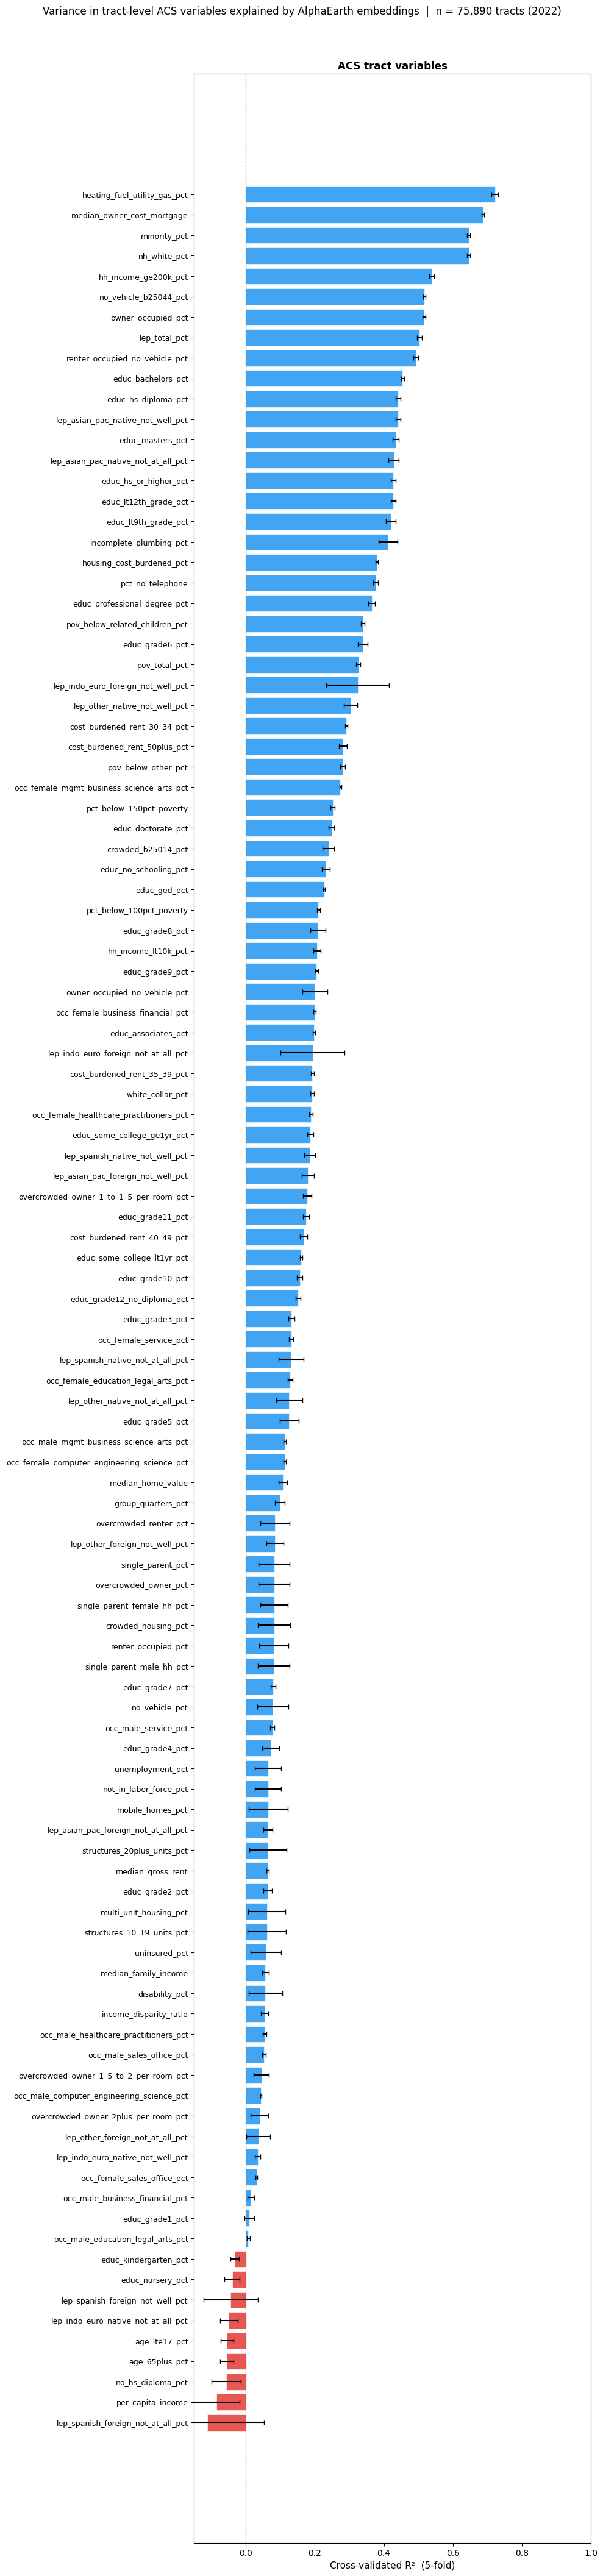

Done — 110 ACS variables evaluated


group,variable,r2_mean,r2_std,indices
str,str,f64,f64,str
"""ACS""","""heating_fuel_utility_gas_pct""",0.721817,0.009923,"""ADI"""
"""ACS""","""median_owner_cost_mortgage""",0.687157,0.003751,"""ADI"""
"""ACS""","""minority_pct""",0.646034,0.004811,"""SVI"""
"""ACS""","""nh_white_pct""",0.646034,0.004811,"""SVI"""
"""ACS""","""hh_income_ge200k_pct""",0.538627,0.007161,"""ADI"""
…,…,…,…,…
"""ACS""","""educ_hs_diploma_pct""",0.441758,0.007244,"""ADI"""
"""ACS""","""lep_asian_pac_native_not_well_…",0.441607,0.007014,"""SVI"""
"""ACS""","""educ_masters_pct""",0.434604,0.008603,"""ADI"""


In [42]:
def plot_r2_bars(ax: plt.Axes, data: pl.DataFrame, title: str) -> None:
    data_s = data.sort("r2_mean")
    labels = data_s["variable"].to_list()
    means  = data_s["r2_mean"].to_list()
    stds   = data_s["r2_std"].to_list()
    colors = ["#2196F3" if v >= 0 else "#E53935" for v in means]
    ax.barh(labels, means, xerr=stds, color=colors, capsize=3,
            alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Cross-validated R²  (5-fold)", fontsize=11)
    ax.set_xlim(-0.15, 1.0)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="y", labelsize=9)


acs_results = results_df.filter(pl.col("group") == "ACS")
n_acs = len(acs_results)

fig, ax = plt.subplots(figsize=(10, max(8, 0.38 * n_acs)))
plot_r2_bars(ax, acs_results, "ACS tract variables")

plt.suptitle(
    f"Variance in tract-level ACS variables explained by AlphaEarth embeddings  |  "
    f"n = {len(df):,} tracts (2022)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "r2_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Done — {n_acs} ACS variables evaluated")
acs_results.head(15)

## Q2: Embeddings vs. ReADI for predicting CDC PLACES health outcomes

For each PLACES health measure we compare three predictor sets using a **held-out states** design (20% of states withheld for evaluation, 80% used for training). Held-out states prevent spatial autocorrelation from inflating embedding performance and simulate the real-world use case of applying a model in new geography.

Models compared:
- **ReADI alone** — single national percentile-rank score
- **Embeddings alone** — 320 AlphaEarth embedding stats + tract area (ALAND, AWATER)
- **ReADI + Embeddings** — both combined; gap over ReADI-alone shows incremental value of embeddings

In [43]:
FIPS_TO_ABBR = {
    "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT",
    "10":"DE","11":"DC","12":"FL","13":"GA","15":"HI","16":"ID","17":"IL",
    "18":"IN","19":"IA","20":"KS","21":"KY","22":"LA","23":"ME","24":"MD",
    "25":"MA","26":"MI","27":"MN","28":"MS","29":"MO","30":"MT","31":"NE",
    "32":"NV","33":"NH","34":"NJ","35":"NM","36":"NY","37":"NC","38":"ND",
    "39":"OH","40":"OK","41":"OR","42":"PA","44":"RI","45":"SC","46":"SD",
    "47":"TN","48":"TX","49":"UT","50":"VT","51":"VA","53":"WA","54":"WV",
    "55":"WI","56":"WY",
}

# --- Load ReADI and join to existing merged dataframe ---
readi = (
    pl.read_csv(DATA_DIR / "ReADI_CT_2022.csv", infer_schema_length=5_000)
    .select(["GEOID", "ReADI_CT_NR"])
    .with_columns(pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
    .drop("GEOID")
)

df2 = (
    df.join(readi, on="tract_fips", how="inner")
      .with_columns(pl.col("tract_fips").str.slice(0, 2).alias("state_fips"))
)

# --- Define state holdout split (20% of states, seed=42) ---
all_states = sorted(df2["state_fips"].unique().to_list())
rng = np.random.default_rng(42)
holdout_states = set(rng.choice(all_states, size=max(1, round(0.2 * len(all_states))), replace=False).tolist())
train_states   = set(all_states) - holdout_states

df2_pd     = df2.to_pandas()
train_mask = df2_pd["state_fips"].isin(train_states).to_numpy()
test_mask  = df2_pd["state_fips"].isin(holdout_states).to_numpy()

READI_FEATS    = ["ReADI_CT_NR"]
COMBINED_FEATS = READI_FEATS + FEATURE_COLS

holdout_abbrs = sorted(FIPS_TO_ABBR.get(s, s) for s in holdout_states)
print(f"Training states : {len(train_states)}  ({train_mask.sum():,} tracts)")
print(f"Held-out states : {len(holdout_states)}  ({test_mask.sum():,} tracts)")
print(f"Held-out states : {holdout_abbrs}")

Training states : 39  (55,215 tracts)
Held-out states : 10  (20,664 tracts)
Held-out states : ['AR', 'CA', 'GA', 'MA', 'MD', 'NC', 'ND', 'NH', 'SC', 'WA']


In [44]:
%%capture
def fit_eval(feat_cols: list[str], y: np.ndarray, train: np.ndarray, test: np.ndarray) -> float:
    """Fit LightGBM on train rows, return R² on test rows."""
    X_tr = df2_pd.loc[train, feat_cols].to_numpy(dtype=float)
    X_te = df2_pd.loc[test,  feat_cols].to_numpy(dtype=float)
    model = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, random_state=42, verbosity=-1,
    )
    model.fit(X_tr, y[train])
    return float(r2_score(y[test], model.predict(X_te)))


_q2_cache = OUTPUTS_DIR / "places_reg.csv"

if USE_CACHED and _q2_cache.exists():
    results_q2_df = pl.read_csv(_q2_cache)
else:
    results_q2 = []
    for col in PLACES_MEASURES:
        if col not in df2_pd.columns:
            continue
        y = df2_pd[col].to_numpy(dtype=float)
        valid       = ~np.isnan(y)
        train_valid = train_mask & valid
        test_valid  = test_mask  & valid
        if train_valid.sum() < 100 or test_valid.sum() < 50:
            continue

        for feat_cols, model_name in [
            (READI_FEATS,    "ReADI"),
            (FEATURE_COLS,   "Embeddings"),
            (COMBINED_FEATS, "ReADI + Embeddings"),
        ]:
            r2 = fit_eval(feat_cols, y, train_valid, test_valid)
            results_q2.append({"outcome": col, "model": model_name, "r2": r2,
                                "n_train": int(train_valid.sum()), "n_test": int(test_valid.sum())})

    results_q2_df = pl.DataFrame(results_q2)
    results_q2_df.write_csv(_q2_cache)

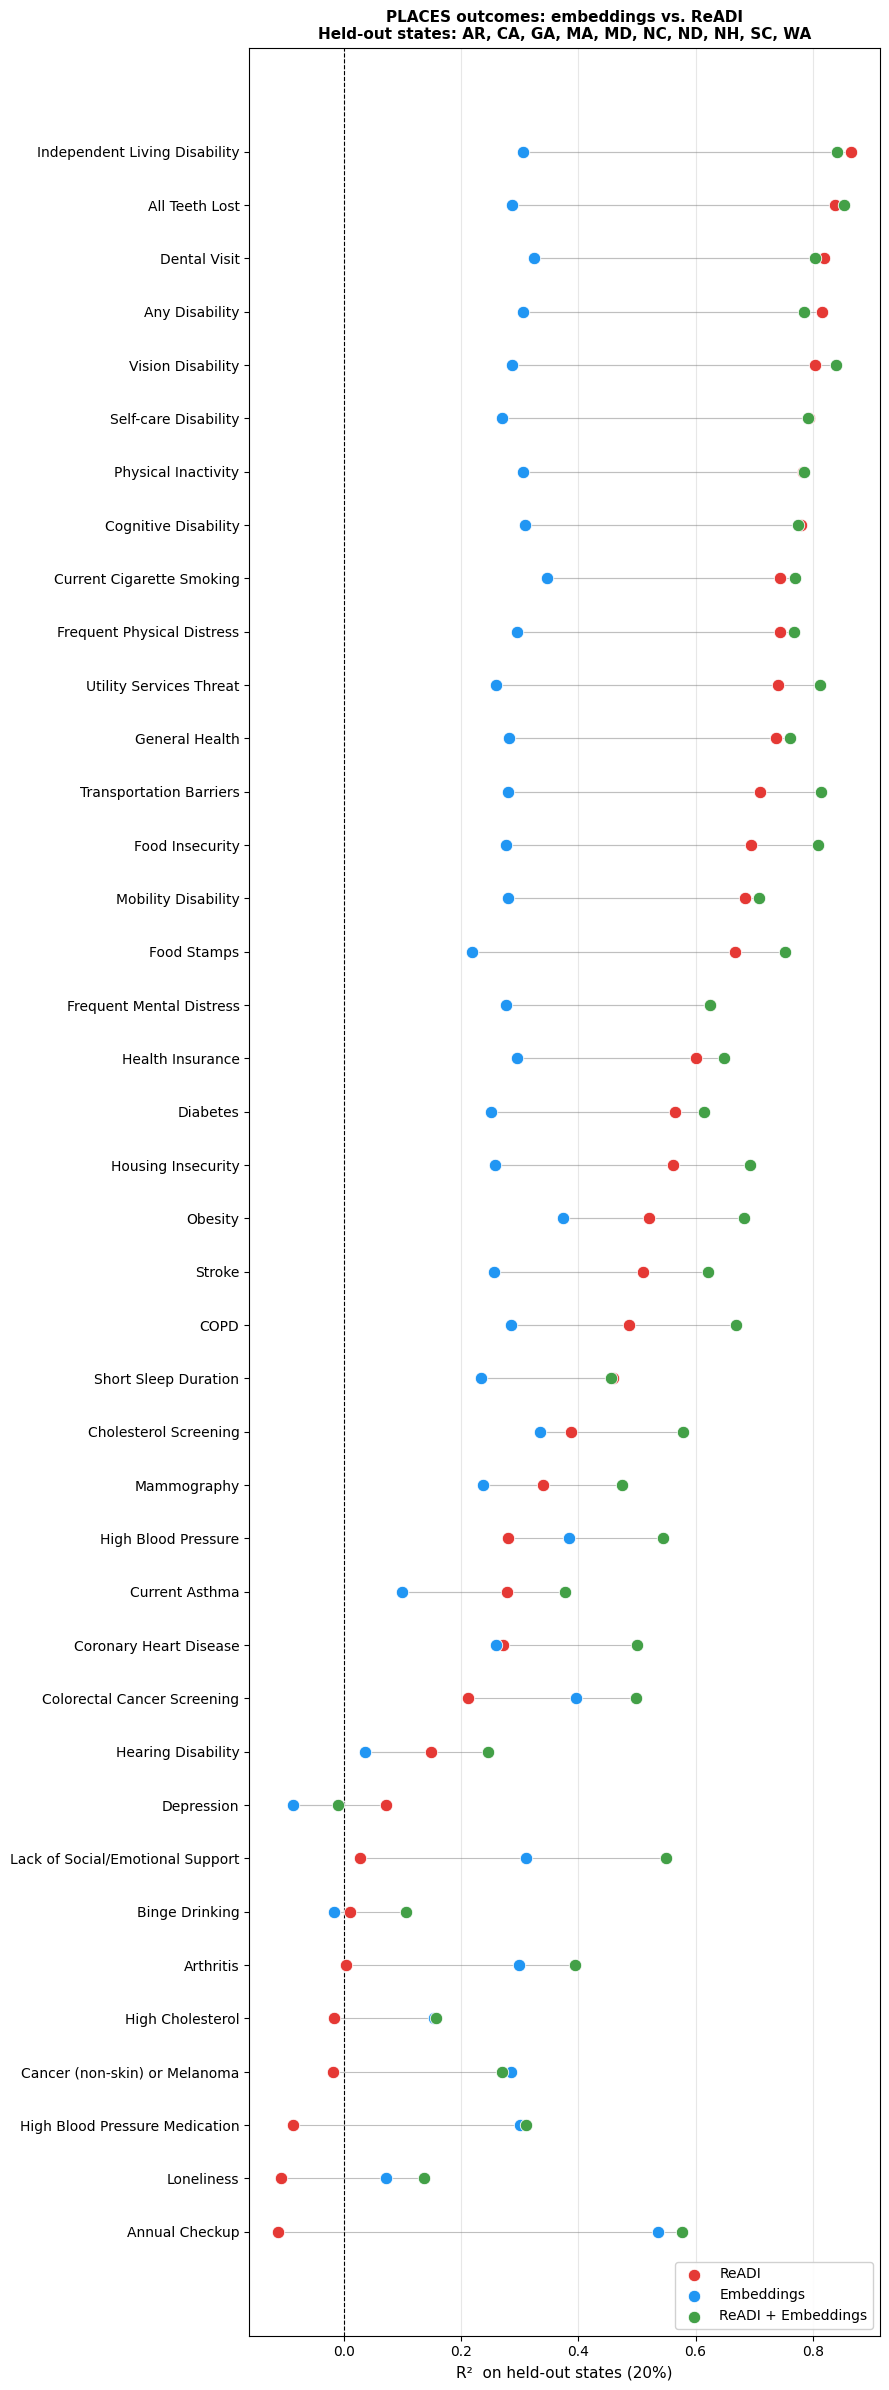

outcome,ReADI,Embeddings,ReADI + Embeddings
str,f64,f64,f64
"""INDEPLIVE""",0.86588,0.305688,0.842115
"""TEETHLOST""",0.837543,0.287672,0.852908
"""DENTAL""",0.819324,0.324778,0.80395
"""DISABILITY""",0.815416,0.306188,0.785835
"""VISION""",0.803435,0.286515,0.839262
…,…,…,…
"""HIGHCHOL""",-0.016453,0.154377,0.156891
"""CANCER""",-0.018842,0.285172,0.270083
"""BPMED""",-0.087565,0.29984,0.311525


In [45]:
MODEL_ORDER  = ["ReADI", "Embeddings", "ReADI + Embeddings"]
MODEL_COLORS = {"ReADI": "#E53935", "Embeddings": "#2196F3", "ReADI + Embeddings": "#43A047"}

readi_r2 = (
    results_q2_df.filter(pl.col("model") == "ReADI")
    .sort("r2")
    .select("outcome")
    .to_series()
    .to_list()
)
readi_r2_labels = [PLACES_LABELS.get(o, o) for o in readi_r2]

fig, ax = plt.subplots(figsize=(9, max(4, 0.6 * len(readi_r2))))

for model_name in MODEL_ORDER:
    sub = (
        results_q2_df.filter(pl.col("model") == model_name)
        .with_columns(pl.col("outcome").cast(pl.Enum(readi_r2)))
        .sort("outcome")
    )
    ys     = [readi_r2.index(o) for o in sub["outcome"].to_list()]
    r2vals = sub["r2"].to_list()
    ax.scatter(r2vals, ys, color=MODEL_COLORS[model_name], label=model_name,
               zorder=3, s=80, edgecolors="white", linewidths=0.6)

for i, outcome in enumerate(readi_r2):
    row = results_q2_df.filter(pl.col("outcome") == outcome).sort("model")
    r2s = {r["model"]: r["r2"] for r in row.iter_rows(named=True)}
    xs  = [r2s.get(m, np.nan) for m in MODEL_ORDER]
    ax.plot(xs, [i] * 3, color="grey", linewidth=0.8, zorder=2, alpha=0.5)

ax.set_yticks(range(len(readi_r2)))
ax.set_yticklabels(readi_r2_labels, fontsize=10)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("R²  on held-out states (20%)", fontsize=11)
ax.set_title(
    f"PLACES outcomes: embeddings vs. ReADI\n"
    f"Held-out states: {', '.join(holdout_abbrs)}",
    fontsize=11, fontweight="bold",
)
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "places_reg.png", dpi=150, bbox_inches="tight")
plt.show()

results_q2_df.pivot(on="model", index="outcome", values="r2").sort("ReADI", descending=True)

## Q3: What amount of the variation in tract-level CDC PLACES data that cannot be explained by social risk indices *can* be explained by embeddings?
First, we'll use LightGBM to allow for non-linear relationships between ReADI and CDC PLACES data. Second, we'll collect those residuals and use them as the outcome of a LightGBM analysis with embeddings as the exposure of interest.

Note that this is different from conventional "partialing out", since we do not assume a linear relationship. By allowing a non-linear relationship between ReADI and tract-level health outcomes, then performing that regression first, we produce a *conservative* estimate of the residual that can be explained by embeddings. 

In [46]:
%%capture
def residual_r2(
    col: str,
    y: np.ndarray,
    train_valid: np.ndarray,
    test_valid: np.ndarray,
) -> dict:
    """
    Two-stage nonlinear residual analysis on held-out states.

    Stage 1 — LightGBM(outcome ~ ReADI): fit on train states, predict on both
              splits to get out-of-sample residuals on test states.
    Stage 2 — LightGBM(residuals ~ embeddings): fit on train residuals,
              evaluate on test residuals.

    Returns a dict with the stage-1 R², residual R², and implied absolute
    additional variance explained (residual_r2 × (1 − stage1_r2)).
    """
    lgbm_kw = dict(n_estimators=300, learning_rate=0.05, num_leaves=31,
                   min_child_samples=20, random_state=42, verbosity=-1)

    # --- Stage 1: ReADI → outcome ---
    X_r_tr = df2_pd.loc[train_valid, READI_FEATS].to_numpy(dtype=float)
    X_r_te = df2_pd.loc[test_valid,  READI_FEATS].to_numpy(dtype=float)

    m1 = lgb.LGBMRegressor(**lgbm_kw)
    m1.fit(X_r_tr, y[train_valid])

    resid_train = y[train_valid] - m1.predict(X_r_tr)
    resid_test  = y[test_valid]  - m1.predict(X_r_te)
    r2_s1 = float(r2_score(y[test_valid], m1.predict(X_r_te)))

    # --- Stage 2: embeddings → residuals ---
    X_e_tr = df2_pd.loc[train_valid, FEATURE_COLS].to_numpy(dtype=float)
    X_e_te = df2_pd.loc[test_valid,  FEATURE_COLS].to_numpy(dtype=float)

    m2 = lgb.LGBMRegressor(**lgbm_kw)
    m2.fit(X_e_tr, resid_train)

    r2_resid = float(r2_score(resid_test, m2.predict(X_e_te)))

    additional_var = max(0.0, r2_resid) * max(0.0, 1.0 - r2_s1)

    return {
        "outcome":        col,
        "r2_readi":       r2_s1,
        "r2_residual":    r2_resid,
        "additional_var": additional_var,
        "n_train":        int(train_valid.sum()),
        "n_test":         int(test_valid.sum()),
    }


_q3_cache = OUTPUTS_DIR / "places_residual.csv"

if USE_CACHED and _q3_cache.exists():
    results_q3_df = pl.read_csv(_q3_cache)
else:
    results_q3 = []
    for col in PLACES_MEASURES:
        if col not in df2_pd.columns:
            continue
        y = df2_pd[col].to_numpy(dtype=float)
        valid       = ~np.isnan(y)
        train_valid = train_mask & valid
        test_valid  = test_mask  & valid
        if train_valid.sum() < 100 or test_valid.sum() < 50:
            continue
        results_q3.append(residual_r2(col, y, train_valid, test_valid))

    results_q3_df = pl.DataFrame(results_q3).sort("r2_residual", descending=True)
    results_q3_df.write_csv(_q3_cache)

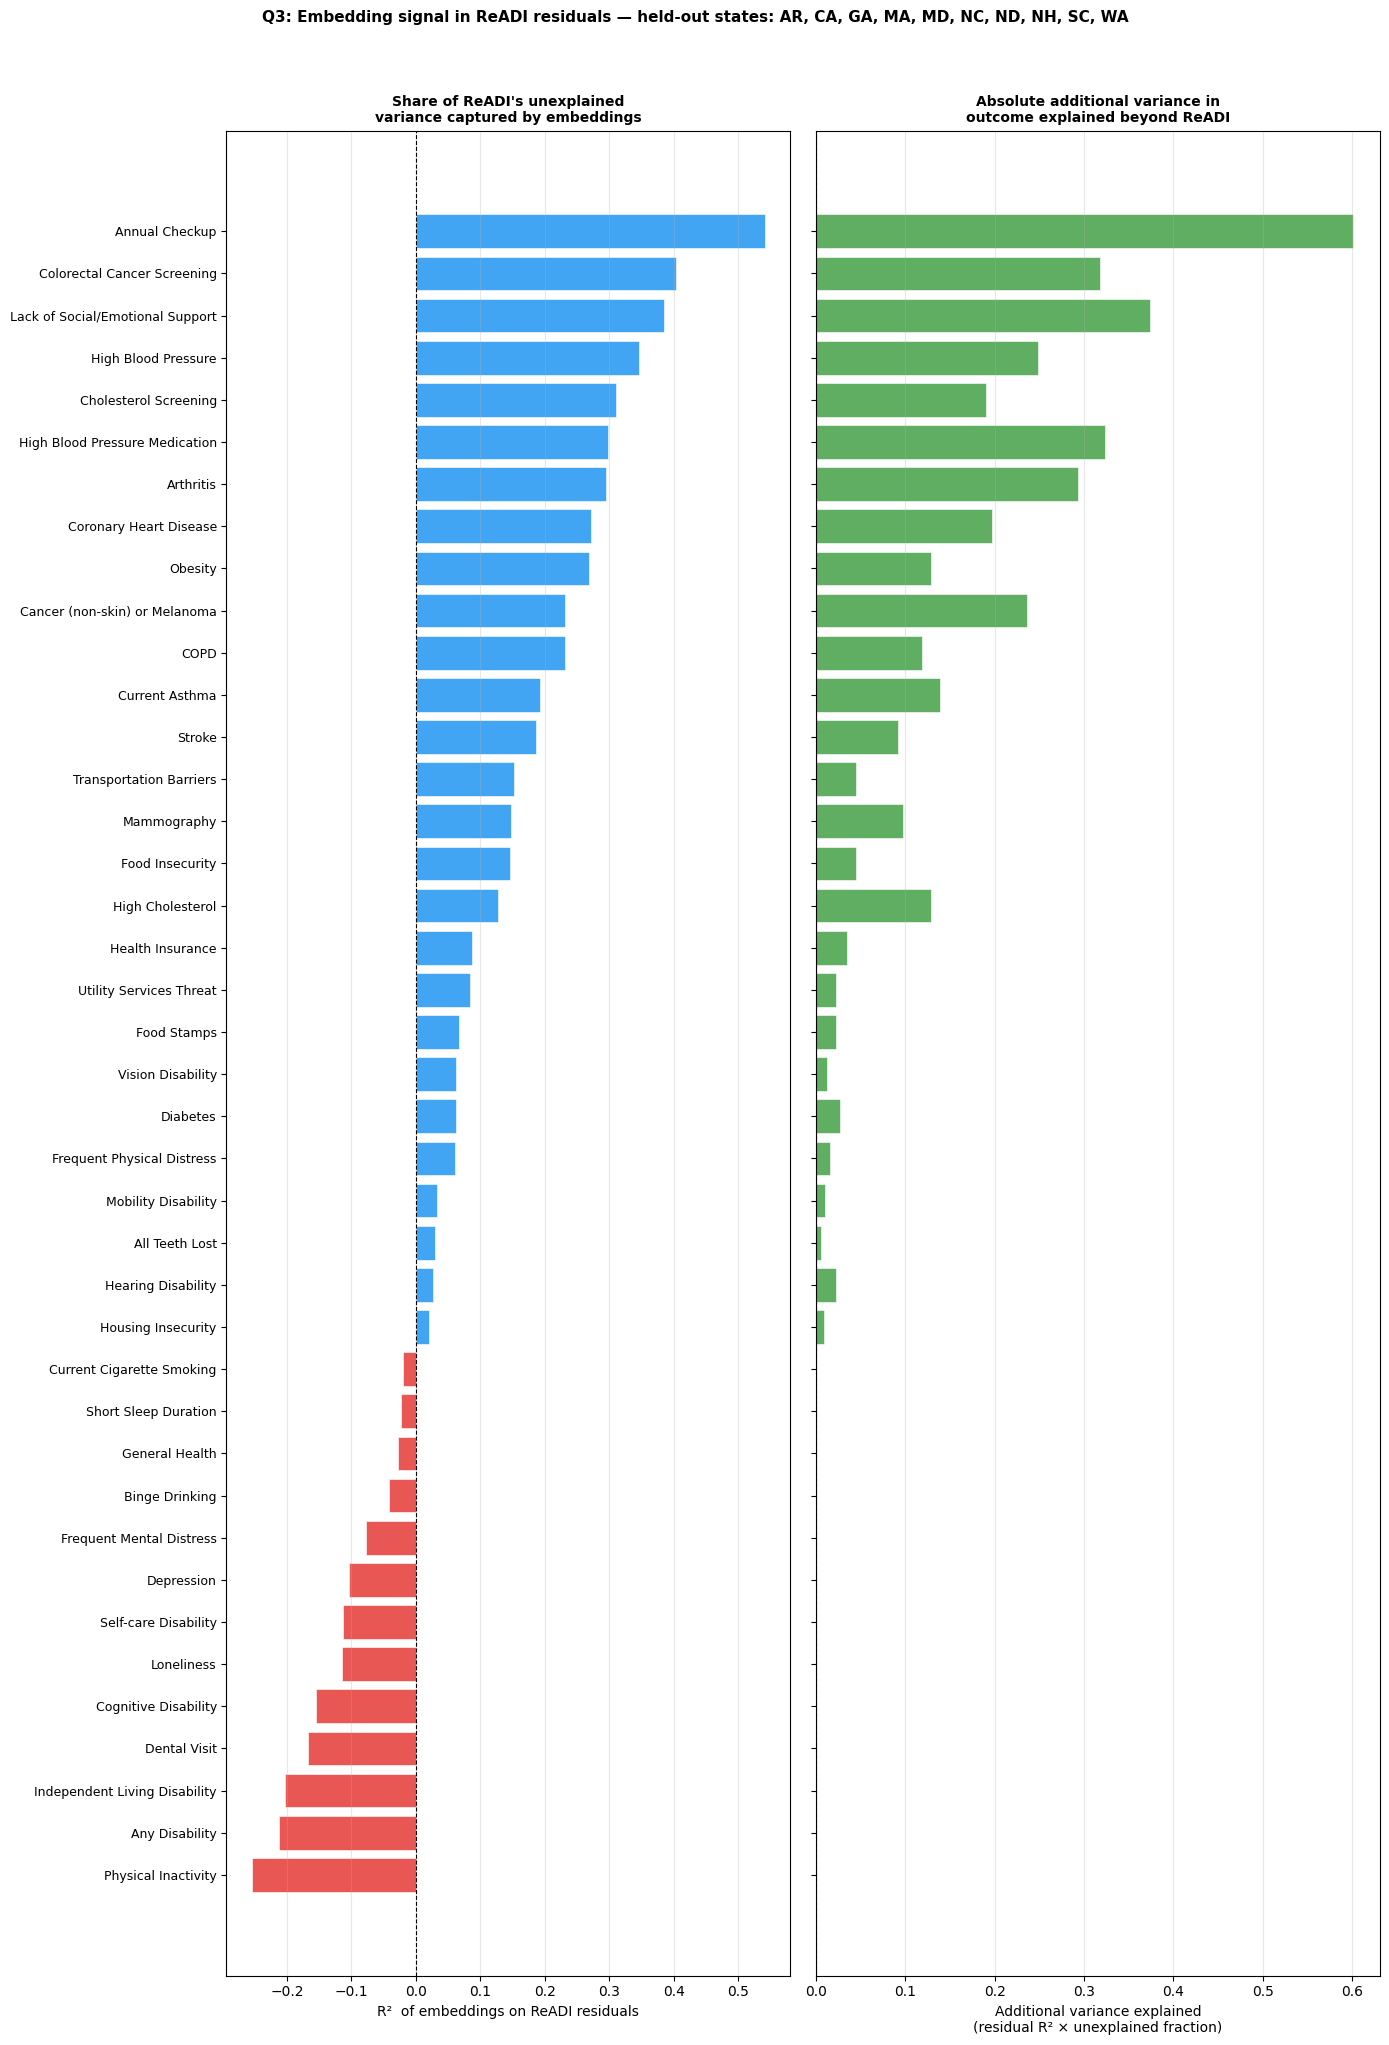

Done — 40 outcomes evaluated


outcome,r2_readi,r2_residual,additional_var,n_train,n_test
str,f64,f64,f64,i64,i64
"""CHECKUP""",-0.112656,0.540547,0.601442,50745,20664
"""COLON_SCREEN""",0.211249,0.403675,0.318399,55214,20663
"""EMOTIONSPT""",0.027838,0.384956,0.37424,34653,18941
"""BPHIGH""",0.27925,0.345075,0.248713,50745,20664
"""CHOLSCREEN""",0.388209,0.310648,0.190052,50745,20664
…,…,…,…,…,…
"""COGNITION""",0.779992,-0.155402,0.0,50745,20664
"""DENTAL""",0.819324,-0.167775,0.0,55215,20664
"""INDEPLIVE""",0.86588,-0.202099,0.0,50745,20664


In [47]:
plot_df = results_q3_df.sort("r2_residual")
outcomes       = plot_df["outcome"].to_list()
outcome_labels = [PLACES_LABELS.get(o, o) for o in outcomes]
r2_resid   = plot_df["r2_residual"].to_list()
additional = plot_df["additional_var"].to_list()

y_pos = np.arange(len(outcomes))
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, 0.5 * len(outcomes))),
                         sharey=True, gridspec_kw={"width_ratios": [1, 1]})

ax = axes[0]
colors = ["#2196F3" if v >= 0 else "#E53935" for v in r2_resid]
ax.barh(y_pos, r2_resid, color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("R²  of embeddings on ReADI residuals", fontsize=10)
ax.set_title("Share of ReADI's unexplained\nvariance captured by embeddings",
             fontsize=10, fontweight="bold")
ax.set_yticks(y_pos)
ax.set_yticklabels(outcome_labels, fontsize=9)
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
ax.barh(y_pos, additional, color="#43A047", alpha=0.85, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Additional variance explained\n(residual R² × unexplained fraction)", fontsize=10)
ax.set_title("Absolute additional variance in\noutcome explained beyond ReADI",
             fontsize=10, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    f"Q3: Embedding signal in ReADI residuals — held-out states: {', '.join(holdout_abbrs)}",
    fontsize=11, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "places_residual.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Done — {len(results_q3_df)} outcomes evaluated")
results_q3_df

## Q4: How much heterogeneity is there in embedding performance across states? Across rural vs urban areas? 
For the first question, perform statewise regressions with ReADI only and embeddings only. Average R² across PLACES outcomes and use a scatterplot to compare average ReADI correlation versus average embedding correlation by state. For the second question, separate tracts into deciles by area. Perform decile-wise regressions for each of the 40 outcomes by ReADI only and by embeddings only. Average R² within deciles for each representation type, and plot using a scatter plot.


In [48]:
%%capture
_q4s_cache = OUTPUTS_DIR / "q4_state.csv"
_q4d_cache = OUTPUTS_DIR / "q4_decile.csv"

if USE_CACHED and _q4s_cache.exists() and _q4d_cache.exists():
    results_q4_state_df  = pl.read_csv(_q4s_cache)
    results_q4_decile_df = pl.read_csv(_q4d_cache)
else:
    X_readi_all = df2_pd[READI_FEATS].to_numpy(dtype=float)
    X_emb_all   = df2_pd[FEATURE_COLS].to_numpy(dtype=float)

    def cv_r2_subset(X: np.ndarray, y: np.ndarray, n_splits: int = 3) -> float:
        """3-fold CV R² on a subset. Returns NaN if too few samples.

        Uses lighter hyperparameters (100 trees, min_child_samples=20) vs. the
        primary analyses because this runs inside a tight state × outcome loop
        and we only need relative comparisons, not precise absolute estimates.
        """
        if len(y) < n_splits * 5:
            return np.nan
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        for tr, va in kf.split(X):
            m = lgb.LGBMRegressor(
                n_estimators=100, learning_rate=0.05, num_leaves=31,
                min_child_samples=20, random_state=42, verbosity=-1,
            )
            m.fit(X[tr], y[tr])
            scores.append(r2_score(y[va], m.predict(X[va])))
        return float(np.nanmean(scores))

    # ── Q4a: State-wise ───────────────────────────────────────────────────────
    results_q4_state = []
    for state_fips in sorted(df2_pd["state_fips"].unique()):
        state_mask = (df2_pd["state_fips"] == state_fips).to_numpy()
        if state_mask.sum() < 50:
            continue
        state_abbr = FIPS_TO_ABBR.get(state_fips, state_fips)

        r2s_readi, r2s_emb = [], []
        for col in PLACES_MEASURES:
            if col not in df2_pd.columns:
                continue
            valid = state_mask & df2_pd[col].notna().to_numpy()
            if valid.sum() < 50:
                continue
            idx = np.where(valid)[0]
            y   = df2_pd[col].iloc[idx].to_numpy(dtype=float)
            r2s_readi.append(cv_r2_subset(X_readi_all[idx], y))
            r2s_emb.append(cv_r2_subset(X_emb_all[idx], y))

        if r2s_readi:
            results_q4_state.append({
                "state":      state_abbr,
                "r2_readi":   float(np.nanmean(r2s_readi)),
                "r2_emb":     float(np.nanmean(r2s_emb)),
                "n_outcomes": len(r2s_readi),
                "n_tracts":   int(state_mask.sum()),
            })

    results_q4_state_df = pl.DataFrame(results_q4_state)
    results_q4_state_df.write_csv(_q4s_cache)

    # ── Q4b: Tract-size deciles ───────────────────────────────────────────────
    aland = df2_pd["ALAND"].to_numpy(dtype=float)
    _edges = np.nanpercentile(aland, np.linspace(0, 100, 11))
    _edges[0] -= 1
    decile_labels = np.searchsorted(_edges[1:-1], aland)  # 0–9

    results_q4_decile = []
    for dec in range(10):
        dec_mask = (decile_labels == dec)
        if dec_mask.sum() < 50:
            continue

        r2s_readi, r2s_emb = [], []
        for col in PLACES_MEASURES:
            if col not in df2_pd.columns:
                continue
            valid = dec_mask & df2_pd[col].notna().to_numpy()
            if valid.sum() < 50:
                continue
            idx = np.where(valid)[0]
            y   = df2_pd[col].iloc[idx].to_numpy(dtype=float)
            r2s_readi.append(cv_r2_subset(X_readi_all[idx], y))
            r2s_emb.append(cv_r2_subset(X_emb_all[idx], y))

        if r2s_readi:
            results_q4_decile.append({
                "decile":           dec + 1,
                "median_aland_km2": float(np.median(aland[dec_mask]) / 1e6),
                "r2_readi":         float(np.nanmean(r2s_readi)),
                "r2_emb":           float(np.nanmean(r2s_emb)),
                "n_tracts":         int(dec_mask.sum()),
            })

    results_q4_decile_df = pl.DataFrame(results_q4_decile)
    results_q4_decile_df.write_csv(_q4d_cache)

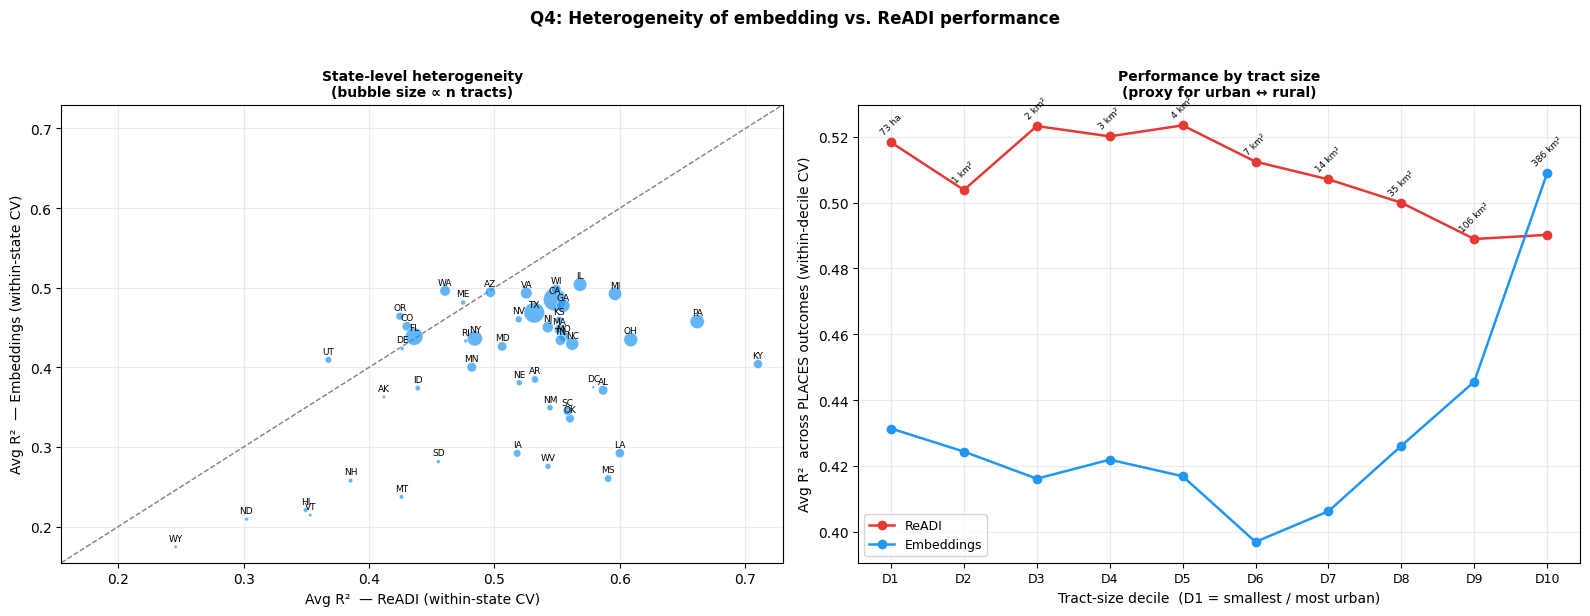

State results:


state,r2_readi,r2_emb,n_outcomes,n_tracts
str,f64,f64,i64,i64
"""IL""",0.568204,0.504109,40,2925
"""WI""",0.549191,0.498397,40,1465
"""WA""",0.460585,0.496066,33,1723
"""AZ""",0.496766,0.494395,40,1688
"""VA""",0.525362,0.49333,40,2090
…,…,…,…,…
"""MT""",0.425927,0.237262,40,316
"""HI""",0.349396,0.220834,40,338
"""VT""",0.353114,0.21445,33,191



Decile results:


decile,median_aland_km2,r2_readi,r2_emb,n_tracts
i64,f64,f64,f64,i64
1,0.731027,0.518309,0.431345,7588
2,1.371883,0.503832,0.424331,7588
3,2.051565,0.523258,0.416092,7588
4,2.821702,0.520127,0.421872,7588
5,4.17829,0.52347,0.416852,7588
6,6.757201,0.512432,0.396884,7587
7,13.521546,0.507061,0.406203,7588
8,34.706583,0.499954,0.426089,7588
9,105.730054,0.488933,0.445581,7588


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: State scatter ────────────────────────────────────────────────────
ax = axes[0]
s_df = results_q4_state_df.to_pandas()
ax.scatter(s_df["r2_readi"], s_df["r2_emb"],
           s=s_df["n_tracts"] / 30, color="#2196F3",
           alpha=0.7, edgecolors="white", linewidths=0.5, zorder=3)

# Label every state
for _, row in s_df.iterrows():
    ax.annotate(row["state"], (row["r2_readi"], row["r2_emb"]),
                fontsize=6.5, ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points")

# y = x diagonal
lim = [min(s_df["r2_readi"].min(), s_df["r2_emb"].min()) - 0.02,
       max(s_df["r2_readi"].max(), s_df["r2_emb"].max()) + 0.02]
ax.plot(lim, lim, color="grey", linewidth=1, linestyle="--", zorder=2)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Avg R²  — ReADI (within-state CV)", fontsize=10)
ax.set_ylabel("Avg R²  — Embeddings (within-state CV)", fontsize=10)
ax.set_title("State-level heterogeneity\n(bubble size ∝ n tracts)", fontsize=10, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.5); ax.axvline(0, color="black", linewidth=0.5)
ax.grid(alpha=0.25)

# ── Panel 2: Tract-size decile line plot ──────────────────────────────────────
ax = axes[1]
d_df = results_q4_decile_df.sort("decile").to_pandas()

ax.plot(d_df["decile"], d_df["r2_readi"],
        color="#E53935", marker="o", linewidth=1.8, markersize=6, label="ReADI")
ax.plot(d_df["decile"], d_df["r2_emb"],
        color="#2196F3", marker="o", linewidth=1.8, markersize=6, label="Embeddings")

# Annotate median tract area at each decile
for _, row in d_df.iterrows():
    area_str = (f"{row['median_aland_km2']:.0f} km²"
                if row["median_aland_km2"] >= 1
                else f"{row['median_aland_km2']*100:.0f} ha")
    ax.annotate(area_str, (row["decile"], max(row["r2_readi"], row["r2_emb"])),
                fontsize=6.5, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points", rotation=45)

ax.set_xticks(d_df["decile"])
ax.set_xticklabels([f"D{d}" for d in d_df["decile"]], fontsize=9)
ax.set_xlabel("Tract-size decile  (D1 = smallest / most urban)", fontsize=10)
ax.set_ylabel("Avg R²  across PLACES outcomes (within-decile CV)", fontsize=10)
ax.set_title("Performance by tract size\n(proxy for urban ↔ rural)", fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.suptitle("Q4: Heterogeneity of embedding vs. ReADI performance",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "q4_heterogeneity.png", dpi=150, bbox_inches="tight")
plt.show()

print("State results:")
display(results_q4_state_df.sort("r2_emb", descending=True))
print("\nDecile results:")
display(results_q4_decile_df)

## Q5: Embeddings vs. ReADI for predicting individual outcomes

We compare three sets of individual chronic health conditions from AFC (chronic kidney disease, diabetes, hypertension) using a **held-out states** design (20% of states withheld for evaluation, 80% used for training). Held-out states prevent spatial autocorrelation from inflating embedding performance and simulate the real-world use case of applying a model in new geography.

Models compared:
- **ReADI alone** — single national percentile-rank score
- **Embeddings alone** — 320 AlphaEarth embedding stats + tract area (ALAND, AWATER)
- **ReADI + Embeddings** — both combined; gap over ReADI-alone shows incremental value of embeddings

> [!NOTE]
> This must be done on a secure server due to the use of individual-level data